# 준비준비

In [ ]:
## 1번 실행 -> 런타임 다시 시작 -> 2번 실행 -> 3번 실행

## 1번

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 49 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (4,952 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 123621 files and dire

In [ ]:
## 2번

import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')

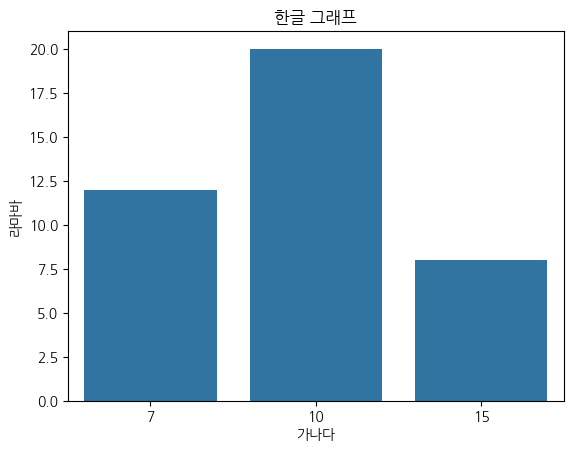

In [ ]:
## 3번

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 나눔고딕 폰트 경로 설정
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()
plt.rc('font', family=font_name)

# 그래프 그리기 예시
data = {'가나다': [10, 15, 7], '라마바': [20, 8, 12]}
df = pd.DataFrame(data)
sns.barplot(data=df, x='가나다', y='라마바')
plt.title('한글 그래프')
plt.show()


# 시작

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 다시 시작

In [ ]:
# 필요한 라이브러리 임포트
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop

데이터 불러오기

In [ ]:
# 데이터 불러오기
df = pd.read_excel('/content/drive/MyDrive/IDS/amaxon reviews 2023/dataset/processing_Subscription Boxes_Reviews_ver01.xlsx')
data = df[['rating', 'text', 'parent_asin', 'user_id']]
data = data.dropna()

texts = data['text'].values
ratings = data['rating'].values
items = data['parent_asin'].values
users = data['user_id'].values

# 텍스트 데이터를 토큰화
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index
max_sequence_length = 300  # 논문에서 사용한 최대 길이
data_padded = pad_sequences(sequences, maxlen=max_sequence_length)

사전 학습 Glove

In [ ]:
# Glove 임베딩 로드
def load_glove_embeddings(glove_path, word_index, embedding_dim=50):
    embeddings_index = {}
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs

    embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))
    for word, i in word_index.items():
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

    return embedding_matrix

In [ ]:
embedding_dim = 50
glove_path = '/content/drive/MyDrive/IDS/amaxon reviews 2023/glove.6B.50d.txt'
embedding_matrix = load_glove_embeddings(glove_path, word_index, embedding_dim)

전처리

In [ ]:
# 아이템 및 사용자 데이터 전처리
from sklearn.preprocessing import LabelEncoder
item_encoder = LabelEncoder()
user_encoder = LabelEncoder()
item_encoded = item_encoder.fit_transform(items)
user_encoded = user_encoder.fit_transform(users)

# 데이터 분할 (train:val:test = 8:1:1)
X_text_train, X_text_temp, X_item_train, X_item_temp, y_train, y_temp = train_test_split(
    data_padded, item_encoded, ratings, test_size=0.2, random_state=42)

X_text_val, X_text_test, X_item_val, X_item_test, y_val, y_test = train_test_split(
    X_text_temp, X_item_temp, y_temp, test_size=0.5, random_state=42)

DeepCoNN 구조

In [ ]:
# 하이퍼파라미터 설정
conv_filters = 100
kernel_size = 3
dropout_rate = 0.5
dense_units = 50
learning_rate = 0.002

# 사용자 신경망 (Netu)
user_input = Input(shape=(max_sequence_length,), name='user_input')
user_embedding = Embedding(input_dim=len(word_index) + 1,
                           output_dim=embedding_dim,
                           weights=[embedding_matrix],
                           trainable=False)(user_input)  # input_length 제거
user_conv = Conv1D(conv_filters, kernel_size, activation='relu')(user_embedding)
user_pooling = MaxPooling1D(pool_size=2)(user_conv)
user_flatten = Flatten(name='user_flatten')(user_pooling)
user_dense = Dense(dense_units, activation='relu')(user_flatten)
user_dropout = Dropout(dropout_rate)(user_dense)

# 아이템 신경망 (Neti)
item_input = Input(shape=(1,), name='item_input')
item_embedding = Embedding(input_dim=len(item_encoder.classes_), output_dim=embedding_dim)(item_input)  # input_length 제거
item_flatten = Flatten(name='item_flatten')(item_embedding)
item_dense = Dense(dense_units, activation='relu')(item_flatten)
item_dropout = Dropout(dropout_rate)(item_dense)


In [ ]:
from tensorflow.keras.layers import Lambda


In [ ]:
# 두 신경망 결합 (Factorization Machine 적용)
concat = Concatenate()([user_dropout, item_dropout])

# Factorization Machine 상호작용 계산 함수 (차원 확장 없이 2차원 반환 유지)
def fm_interaction(x):
    sum_square = tf.square(tf.reduce_sum(x, axis=1, keepdims=True))  # 차원 별 합의 제곱
    square_sum = tf.reduce_sum(tf.square(x), axis=1, keepdims=True)  # 각 차원 제곱 후 합
    interaction = 0.5 * (sum_square - square_sum)  # 상호작용 계산
    return interaction  # 2차원 반환 유지

# Lambda 레이어로 Factorization Machine 적용
interaction = Lambda(fm_interaction)(concat)

# Dense 레이어 적용
output = Dense(1, activation='linear')(interaction)



컴파일 + 학습

In [ ]:
from tensorflow.keras.optimizers import Adam

#optimizer
opt = Adam(learning_rate=learning_rate)

# 모델 컴파일
model = Model(inputs=[user_input, item_input], outputs=output)
model.compile(optimizer=opt, loss='mse', metrics=['mae'])

# 모델 학습
history = model.fit([X_text_train, X_item_train], y_train,
                    validation_data=([X_text_val, X_item_val], y_val),
                    batch_size=128, epochs=50)




Epoch 1/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 25.6750 - mae: 3.4283 - val_loss: 3.4270 - val_mae: 1.5317
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.7762 - mae: 1.8009 - val_loss: 2.6763 - val_mae: 1.4257
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.9921 - mae: 1.6691 - val_loss: 2.3779 - val_mae: 1.3322
Epoch 4/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.7383 - mae: 1.6120 - val_loss: 2.4010 - val_mae: 1.3639
Epoch 5/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.5776 - mae: 1.5727 - val_loss: 2.4305 - val_mae: 1.3952
Epoch 6/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.4453 - mae: 1.5498 - val_loss: 2.2877 - val_mae: 1.3302
Epoch 7/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.3434 - mae: 1.5352 - val_loss: 2.2128 - val_mae: 1.3056
Epoch 8/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.2133 - mae: 1.4994 - val_loss: 2.1397 - val_mae: 1.2712
Epoch 9/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - 

In [ ]:
from sklearn.metrics.pairwise import euclidean_distances


In [ ]:
# 사용자와 아이템의 특성을 추출하는 중간 모델 생성
user_feature_model = Model(inputs=model.input[0], outputs=model.get_layer('user_flatten').output)
item_feature_model = Model(inputs=model.input[1], outputs=model.get_layer('item_flatten').output)

# 테스트 데이터에서 사용자와 아이템 특성 벡터 추출
user_features = user_feature_model.predict(X_text_test)
item_features = item_feature_model.predict(X_item_test)

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# 일반적인 평점 예측 함수 정의
def predict_rating_general(user_id, item_id):
    # 특정 사용자의 다른 리뷰들 추출 (현재 예측하려는 아이템 제외)
    user_indices = [index for index, user in enumerate(users) if user == user_id and items[index] != item_id]
    user_indices = [index for index in user_indices if index < len(X_text_test)]  # 인덱스가 범위를 초과하지 않도록 필터링
    user_review_sequences = X_text_test[user_indices]  # 사용자 리뷰의 시퀀스 형태

    # 특정 아이템에 대한 다른 사용자들의 리뷰 추출 (현재 예측하려는 사용자 제외)
    item_indices = [index for index, item in enumerate(items) if item == item_id and users[index] != user_id]
    item_indices = [index for index in item_indices if index < len(item_features)]  # 인덱스가 범위를 초과하지 않도록 필터링
    item_review_vectors = item_features[item_indices]

    # 사용자 리뷰와 아이템 리뷰가 모두 존재하는지 확인
    if len(user_review_sequences) == 0 or len(item_review_vectors) == 0:
        return None  # 예측 불가한 경우 예외 처리

    # 사용자 리뷰 시퀀스의 평균 계산 (고정된 시퀀스 길이를 유지하기 위해 평균을 내고 다시 패딩)
    user_combined_sequence = np.mean(user_review_sequences, axis=0).astype(int)
    user_combined_sequence = pad_sequences([user_combined_sequence], maxlen=max_sequence_length)

    # 아이템 인덱스 입력 생성
    item_input = np.array([item_encoded[list(items).index(item_id)]]).reshape(1, -1)  # 아이템 인덱스 입력

    # 평점 예측
    predicted_rating = model.predict([user_combined_sequence, item_input])
    return predicted_rating

# 모든 사용자와 모든 아이템에 대해 평점 예측 (리뷰가 없는 경우)
predicted_ratings = []
for user_id in set(users):
    for item_id in set(items):
        # 해당 사용자와 아이템에 대한 예측 평점 계산
        predicted_rating = predict_rating_general(user_id, item_id)
        if predicted_rating is not None:
            predicted_ratings.append((user_id, item_id, predicted_rating[0][0]))

# 예측된 평점 출력
for user_id, item_id, rating in predicted_ratings[:10]:
    # 예측된 일부 결과 출력
    print(f"Predicted Rating for User {user_id} and Item {item_id}: {rating}")


Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

KeyboardInterrupt: 

평가 지표

In [ ]:
# 학습 손실(MSE) 및 검증 손실(MSE)을 플롯으로 시각화
def plot_history(history, test_loss=None, test_mae=None):
    # Loss (MSE)
    plt.figure()
    plt.plot(history.history['loss'], label='Train MSE')
    plt.plot(history.history['val_loss'], label='Validation MSE')
    if test_loss is not None:
        plt.axhline(y=test_loss, color='r', linestyle='--', label='Test MSE')
    plt.title('Model MSE Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.legend()
    plt.show()

    # MAE (평가지표)
    plt.figure()
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    if test_mae is not None:
        plt.axhline(y=test_mae, color='r', linestyle='--', label='Test MAE')
    plt.title('Model MAE')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error')
    plt.legend()
    plt.show()

# 학습 기록(history) 및 테스트 결과 시각화
plot_history(history)